# **Лабораторная работа 2: логистическая регрессия — от EDA к нелинейным границам решений**

[Открыть общедоступную тетрадь в Google Colab](https://colab.research.google.com/github/avkornaev/Intro-to-ML-2026/blob/main/labs/02-logistic-regression-ru.ipynb)

**Ожидаемое время выполнения:** 90 минут  
**Максимальная оценка:** 4 балла  
**Обязательная часть:** восемь заданий `TODO(student)` и семь вопросов на интерпретацию

Если Colab не может открыть репозиторий напрямую, скачайте `02-logistic-regression-ru.ipynb` с сайта курса, откройте [Google Colab](https://colab.research.google.com/) и выберите **Файл → Загрузить блокнот**. Перед редактированием сохраните собственную копию.

Лабораторную работу разработал **Алексей Корнаев** при поддержке ChatGPT (OpenAI) в подготовке и проверке материалов. Ответственность за учебный дизайн, техническую корректность и оценивание несёт преподаватель.

## **1. Исследовательский вопрос**

В лабораторной работе 1 мы рассмотрели полный цикл обучения на примере прямой. Теперь результатом будет класс: **является ли опухоль злокачественной или доброкачественной?** Мы сохраним модель простой, но будем менять представление данных, которое она получает.

Сравним четыре пайплайна:

| Пайплайн | Представление для логистической регрессии | Главный вопрос |
|---|---|---|
| A | все 30 исходных признаков | Что происходит, когда масштабы признаков сильно различаются? |
| B | все 30 стандартизованных признаков | Как масштабирование влияет на оптимизацию? |
| C | две стандартизованные главные компоненты | Что теряется при уменьшении размерности с 30 до 2? |
| D | стандартизованные $u_1,u_2,u_1^2,u_1u_2,u_2^2$ | Поможет ли нелинейное представление в той же плоскости PCA? |

Каждая модель представляет собой логистическую регрессию на PyTorch. Пайплайн D по-прежнему **линеен по обучаемым параметрам**, однако квадратичные входные признаки создают нелинейную границу в исходной плоскости PCA.

### *Цели обучения*

К концу работы вы должны уметь:

- связывать EDA обучающих данных с проверяемыми гипотезами о моделировании;
- объяснять, почему параметры предобработки следует оценивать только по обучающим данным;
- выводить градиент бинарной кросс-энтропии для логистической регрессии и проверять его с помощью autograd;
- реализовывать `Dataset`, `DataLoader`, BCE по логитам, оптимизатор и цикл обучения;
- различать качество оптимизации при фиксированном бюджете и качество предсказаний;
- объяснять PCA как представление, сохраняющее дисперсию, но не оптимизирующее разделение классов;
- объяснять, как модель, линейная по параметрам, может строить нелинейную границу;
- выбирать пайплайн по валидационным данным и использовать тестовые данные только для одной итоговой оценки.

### *Чат — тьютор, а не генератор решений*

Вы можете использовать чат-ассистента для объяснений, последовательных подсказок и отладки. Вы отвечаете за **каждую отправленную строку**, каждый результат и каждый письменный ответ. На защите вас могут попросить изменить или объяснить код.

<details>
<summary><strong>Скопируйте этот текст в качестве первого сообщения в чат и приложите тетрадь</strong></summary>

```text
Ты — мой тьютор по оцениваемой вводной лабораторной работе по машинному обучению, посвящённой логистической регрессии. Работай в режиме помощи.

Помогай мне разобраться в тетради с помощью объяснений, последовательных подсказок, наводящих вопросов и отладки. Не выполняй за меня задания TODO(student), не пиши целиком оцениваемые ячейки и не отвечай за меня на итоговые вопросы. Сначала спроси, какое задание я выполняю, какого результата ожидаю и что уже попробовал.

Давай по одной небольшой подсказке за раз. Если необходим код, показывай только минимальный иллюстративный фрагмент, а не полное решение. Проси меня предсказать формы тензоров и результаты до запуска кода. При отладке помогай найти причину ошибки, но исправление оставляй мне. После каждого шага проверяй моё понимание коротким вопросом.

Обращай особое внимание на разделение данных на обучающую, валидационную и тестовую части; обучение предобработки только на обучающих данных; различие логитов и вероятностей; BCEWithLogitsLoss; формы тензоров; градиенты; Dataset/DataLoader; кривые обучения; PCA; полиномиальные признаки; границы решений и метрики классификации. Никогда не предлагай ослабить проверку assert, изменить разбиение или использовать тестовые результаты для выбора модели.

Я отвечаю за проверку, понимание и объяснение каждой отправленной строки и каждого вывода.
```

Никогда не отправляйте в чат пароли, токены, закрытые ссылки, персональные данные или идентифицируемую информацию о пациентах.

</details>

## **2. Подготовка среды и вспомогательные функции**

В Google Colab необходимые пакеты обычно уже установлены. В другой среде команда тетради начинается с `!`, например:

```python
# Раскомментируйте, только если пакет отсутствует:
# !pip install torch scikit-learn pandas matplotlib seaborn
```

Следующие ячейки содержат импорты и готовые вспомогательные функции для построения графиков и отчётов. Они скрывают повторяющийся оформительский код; основные учебные задачи — градиенты, загрузка данных, модель, функция потерь и обучение — далее остаются явными.

In [39]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)

sns.set_theme(style="whitegrid", context="notebook")
DEVICE = torch.device("cpu")
print("PyTorch", torch.__version__, "| устройство:", DEVICE)

PyTorch 2.14.0+cpu | устройство: cpu


In [40]:
# Вспомогательные функции: готовый код для оценки и построения графиков.
def as_float_tensor(values):
    return torch.as_tensor(values, dtype=torch.float32, device=DEVICE)


def predict_probabilities(model, features):
    model.eval()
    with torch.no_grad():
        logits = model(as_float_tensor(features)).squeeze(1)
        return torch.sigmoid(logits).cpu().numpy()


def classification_metrics(targets, probabilities, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)
    return {
        "доля верных ответов": accuracy_score(targets, predictions),
        "полнота злокачественного класса": recall_score(targets, predictions),
        "ROC AUC": roc_auc_score(targets, probabilities),
    }


def plot_histories(histories):
    fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
    for ax, (name, history) in zip(axes.flat, histories.items()):
        ax.plot(history["train"], label="обучение")
        ax.plot(history["validation"], label="валидация")
        ax.axvline(history["best_epoch"], color="black", ls=":", lw=1,
                   label="выбранная контрольная точка")
        ax.set(title=name, xlabel="эпоха", ylabel="BCE", yscale="log")
        ax.legend(frameon=False, fontsize=8)
    fig.suptitle("Одинаковый бюджет обучения; разные представления и динамика", y=1.02)
    plt.tight_layout()
    plt.show()


def plot_boundary(ax, model, plane_transform, train_plane, train_targets,
                  val_plane, val_targets, title):
    padding = 1.0
    x_min, x_max = train_plane[:, 0].min() - padding, train_plane[:, 0].max() + padding
    y_min, y_max = train_plane[:, 1].min() - padding, train_plane[:, 1].max() + padding
    gx, gy = np.meshgrid(np.linspace(x_min, x_max, 260),
                         np.linspace(y_min, y_max, 260))
    grid = np.column_stack([gx.ravel(), gy.ravel()])
    probabilities = predict_probabilities(model, plane_transform(grid)).reshape(gx.shape)
    ax.contourf(gx, gy, probabilities, levels=np.linspace(0, 1, 11),
                cmap="RdBu_r", alpha=.28)
    ax.contour(gx, gy, probabilities, levels=[.5], colors="black", linewidths=2)
    ax.scatter(train_plane[:, 0], train_plane[:, 1], c=train_targets,
               cmap="RdBu_r", s=17, alpha=.42, label="обучение")
    ax.scatter(val_plane[:, 0], val_plane[:, 1], c=val_targets,
               cmap="RdBu_r", marker="x", s=42, linewidths=1.3, label="валидация")
    ax.set(title=title, xlabel="$u_1$", ylabel="$u_2$")

## **3. Сначала данные: фиксированное и честное разбиение**

Набор Breast Cancer Wisconsin Diagnostic содержит **569 объектов** и **30 непрерывных признаков**, вычисленных по оцифрованным изображениям материала тонкоигольной аспирационной биопсии молочной железы. Признаки описывают радиус, текстуру, периметр, площадь, гладкость, компактность, вогнутость, симметрию, фрактальную размерность и другие свойства.

В scikit-learn злокачественный класс закодирован как 0, а доброкачественный — как 1. Мы намеренно меняем кодирование:

$y=1$ означает **злокачественную опухоль** (положительный класс), а $y=0$ — **доброкачественную**.

Так полноту по злокачественному классу легко интерпретировать: какую долю злокачественных случаев обнаружила модель?

In [43]:
cancer = load_breast_cancer(as_frame=True)
X_all = cancer.data.copy()
y_all = (cancer.target == 0).astype(np.float32).rename("злокачественная")

print("исходные названия классов:", list(cancer.target_names))
print("признаки:", X_all.shape, "| целевая переменная:", y_all.shape)
display(X_all.head(3))
print("доля злокачественных:", sum(y_all) / len(y_all))
assert X_all.shape == (569, 30)
assert set(y_all.unique()) == {0.0, 1.0}

исходные названия классов: [np.str_('malignant'), np.str_('benign')]
признаки: (569, 30) | целевая переменная: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


доля злокачественных: 0.37258347978910367


In [44]:
# Сначала отделяем тестовую выборку, затем разделяем оставшиеся данные для разработки.
X_development, X_test, y_development, y_test = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_development, y_development, test_size=0.25,
    stratify=y_development, random_state=SEED
)

split_summary = pd.DataFrame({
    "объекты": [len(X_train), len(X_val)],
    "доля злокачественных": [y_train.mean(), y_val.mean()],
}, index=["обучающая", "валидационная"])
display(split_summary.style.format({"доля злокачественных": "{:.3f}"}))
print("отложено тестовых объектов:", len(X_test), "(метки пока не просматриваются)")

assert len(X_train) + len(X_val) + len(X_test) == 569
assert set(X_train.index).isdisjoint(X_val.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_val.index).isdisjoint(X_test.index)

,объекты,доля злокачественных
обучающая,341,0.372
валидационная,114,0.377


отложено тестовых объектов: 114 (метки пока не просматриваются)


**Обучающая выборка** может использоваться для графиков, оценки преобразований и обновления параметров. **Валидационная выборка** — для выбора пайплайна. **Тестовая выборка** остаётся закрытой до окончательного выбора модели.

Стратификация сохраняет близкие доли классов; она не делает выборки одинаковыми и не отменяет необходимость подходящих метрик.

## **4. EDA только обучающих данных для выбора модели**

EDA — не украшение. Каждое наблюдение должно приводить к гипотезе о модели, которую можно проверить экспериментально.

### *Качество данных и баланс классов*

,значение
обучающих объектов,341
признаков,30
пропущенных значений,0
бесконечных значений,0
повторяющихся строк,0


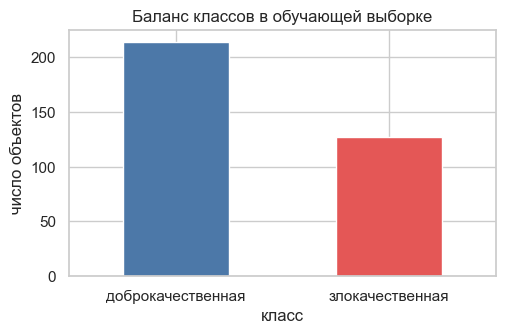

In [6]:
quality = pd.Series({
    "обучающих объектов": len(X_train),
    "признаков": X_train.shape[1],
    "пропущенных значений": int(X_train.isna().sum().sum()),
    "бесконечных значений": int(np.isinf(X_train.to_numpy()).sum()),
    "повторяющихся строк": int(X_train.duplicated().sum()),
})
display(quality.to_frame("значение"))

class_counts = y_train.map({0.0: "доброкачественная", 1.0: "злокачественная"}).value_counts()
ax = class_counts.reindex(["доброкачественная", "злокачественная"]).plot.bar(
    color=["#4C78A8", "#E45756"], rot=0, figsize=(5.5, 3.2)
)
ax.set(title="Баланс классов в обучающей выборке", xlabel="класс", ylabel="число объектов")
plt.show()

assert quality["пропущенных значений"] == 0
assert quality["бесконечных значений"] == 0

### *Масштабы признаков*

<>:9: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:9: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\bulki\AppData\Local\Temp\ipykernel_15816\1931024944.py:9: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  xlabel="признаки, упорядоченные по размаху", ylabel="$\log_{10}$(размаха на обучающей выборке)")


,размах,стандартное отклонение
fractal dimension error,0.022,0.00259
smoothness error,0.0294,0.00297
mean area,2.36e+03,372
worst area,4.07e+03,592


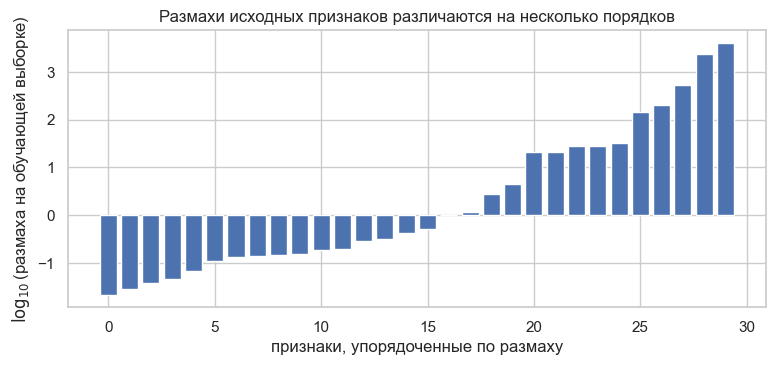

In [7]:
feature_ranges = X_train.max() - X_train.min()
feature_std = X_train.std()
scale_table = pd.DataFrame({"размах": feature_ranges, "стандартное отклонение": feature_std})
display(scale_table.sort_values("размах").iloc[[0, 1, -2, -1]].style.format("{:.3g}"))

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(np.arange(len(feature_ranges)), np.log10(feature_ranges.sort_values()))
ax.set(title="Размахи исходных признаков различаются на несколько порядков",
       xlabel="признаки, упорядоченные по размаху", ylabel="$\log_{10}$(размаха на обучающей выборке)")
plt.show()

Градиентный спуск использует один темп обучения для всех коэффициентов. Если один признак изменяется вблизи $10^{-2}$, а другой — вблизи $10^3$, масштабы соответствующих градиентов могут сильно различаться. Отсюда следует проверяемая гипотеза: **при одинаковом вычислительном бюджете стандартизация может сделать оптимизацию устойчивее**.

### *Распределения и корреляции*

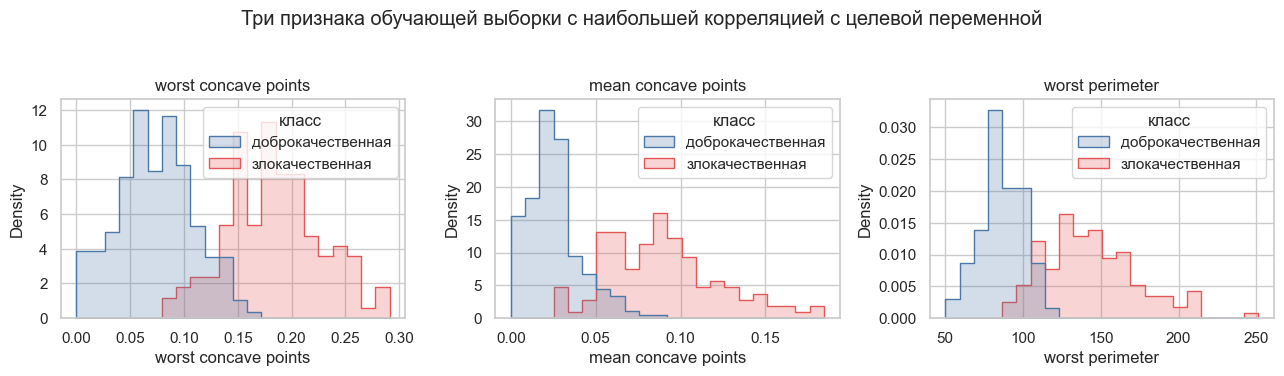

In [8]:
eda_frame = X_train.copy()
eda_frame["злокачественная"] = y_train
eda_frame["класс"] = y_train.map({0.0: "доброкачественная", 1.0: "злокачественная"})
target_correlations = eda_frame.corr(numeric_only=True)["злокачественная"].drop("злокачественная")
strongest_features = target_correlations.abs().nlargest(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, feature in zip(axes, strongest_features):
    sns.histplot(data=eda_frame, x=feature, hue="класс", bins=22,
                 stat="density", common_norm=False, element="step", ax=ax,
                 palette={"доброкачественная": "#4C78A8", "злокачественная": "#E45756"})
    ax.set_title(feature)
fig.suptitle("Три признака обучающей выборки с наибольшей корреляцией с целевой переменной", y=1.04)
plt.tight_layout()
plt.show()

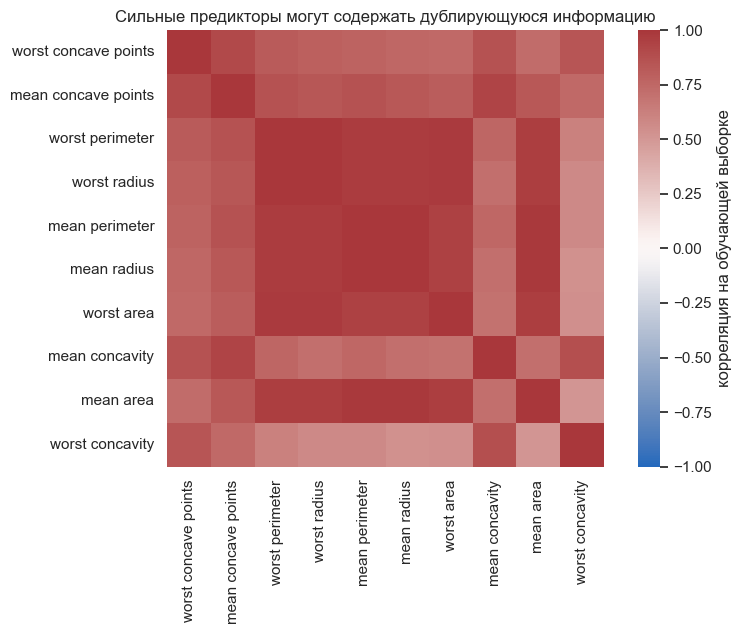

In [9]:
correlated_features = target_correlations.abs().nlargest(10).index
correlation_matrix = X_train[correlated_features].corr()

plt.figure(figsize=(8.5, 6.5))
sns.heatmap(correlation_matrix, cmap="vlag", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "корреляция на обучающей выборке"})
plt.title("Сильные предикторы могут содержать дублирующуюся информацию")
plt.tight_layout()
plt.show()

### *Задание 1/8 — Превратите результаты EDA в гипотезы*

До обучения моделей сформулируйте три кратких предсказания. Опирайтесь на приведённые выше наблюдения.

1. **A и B — масштабирование и оптимизация:** TODO(student)
2. **B и C — снижение размерности:** TODO(student)
3. **C и D — нелинейное представление:** TODO(student)

Это гипотезы, а не обещания. В частности, полиномиальные признаки не обязаны улучшать качество на валидационной выборке.

## **5. Логистическая регрессия: данные → модель → функция потерь → оптимизатор**

Для вектора признаков $x_i$ логистическая регрессия вычисляет **логит**

$$z_i=x_i^T w+b,$$

а затем преобразует его в вероятность с помощью сигмоиды:

$$p_i=\sigma(z_i)=\frac{1}{1+e^{-z_i}}.$$

При пороге 0.5 значение $p_i\geq0.5$ означает прогноз злокачественного класса. Поскольку $\sigma(0)=0.5$, граница решений проходит точно там, где $z_i=0$.

Бинарная кросс-энтропия представляет собой усреднённое отрицательное логарифмическое правдоподобие распределения Бернулли:

$$L=-\frac{1}{N}\sum_i\left[y_i\log p_i+(1-y_i)\log(1-p_i)\right].$$

Мы будем использовать `BCEWithLogitsLoss`: эта функция принимает логиты и численно устойчиво объединяет вычисление сигмоиды и BCE. Во время обучения **не добавляйте** слой сигмоиды внутрь модели.

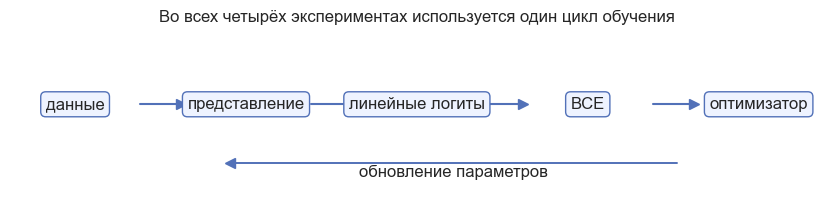

In [10]:
fig, ax = plt.subplots(figsize=(10.5, 2.3))
ax.axis("off")
labels = ["данные", "представление", "линейные логиты", "BCE", "оптимизатор"]
positions = np.linspace(.08, .92, len(labels))
for x, label in zip(positions, labels):
    ax.text(x, .58, label, ha="center", va="center",
            bbox=dict(boxstyle="round", fc="#EEF3FF", ec="#5271B8"))
for left, right in zip(positions[:-1], positions[1:]):
    ax.plot([left + .08, right - .08], [.58, .58], color="#5271B8", lw=1.5)
    ax.plot(right - .08, .58, marker=">", color="#5271B8", ms=7)
ax.plot([.82, .27], [.25, .25], color="#5271B8", lw=1.4)
ax.plot(.27, .25, marker="<", color="#5271B8", ms=7)
ax.text(.545, .17, "обновление параметров", ha="center")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Во всех четырёх экспериментах используется один цикл обучения")
plt.show()

### *Аналитический градиент*

Для матрицы батча $X$, в которой каждая строка соответствует одному объекту, градиенты BCE упрощаются до

$$\frac{\partial L}{\partial w}=\frac{1}{N}X^T(p-y),$$

$$\frac{\partial L}{\partial b}=\frac{1}{N}\sum_i(p_i-y_i).$$

Теперь остаток равен **вероятности минус бинарная метка**. Матрица признаков распределяет этот остаток по коэффициентам.

### *Задание 2/8 — Вычислите аналитические градиенты с помощью тензоров*

In [11]:
def analytical_logistic_gradients(features, targets, weights, bias):
    # признаки: [N, D], метки: [N, 1], веса: [D, 1], смещение: [1]
    # TODO(student): вычислите логиты, вероятности, dL/dw и dL/db.
    raise NotImplementedError("Выполните задание 2")

In [12]:
X_check = torch.tensor([[1.0, -1.0], [0.5, 2.0], [-1.5, 0.3]], dtype=torch.float64)
y_check = torch.tensor([[1.0], [0.0], [1.0]], dtype=torch.float64)
w_check = torch.tensor([[0.2], [-0.4]], dtype=torch.float64, requires_grad=True)
b_check = torch.tensor([0.1], dtype=torch.float64, requires_grad=True)

manual_dw, manual_db = analytical_logistic_gradients(
    X_check, y_check, w_check.detach(), b_check.detach()
)
autograd_loss = nn.BCEWithLogitsLoss()(X_check @ w_check + b_check, y_check)
autograd_loss.backward()

assert manual_dw.shape == w_check.shape
assert manual_db.shape == b_check.shape
assert torch.allclose(manual_dw, w_check.grad, atol=1e-10)
assert torch.allclose(manual_db, b_check.grad, atol=1e-10)
print("аналитический dL/dw:")
print(manual_dw)
print("dL/dw от autograd:")
print(w_check.grad)
print("Задание 2 пройдено: аналитические градиенты совпадают с autograd.")

NotImplementedError: Выполните задание 2

Autograd не аппроксимировал значения функции потерь в соседних точках. Он продифференцировал записанные операции над тензорами и получил тот же градиент при текущих параметрах.

## **6. Построим переиспользуемый пайплайн PyTorch**

### *Задание 3/8 — Реализуйте `Dataset` для классификации*

In [ ]:
class CancerDataset(Dataset):
    def __init__(self, features, targets):
        self.features = as_float_tensor(np.asarray(features))
        self.targets = as_float_tensor(np.asarray(targets)).reshape(-1, 1)
        if len(self.features) != len(self.targets):
            raise ValueError("число объектов и меток должно совпадать")

    def __len__(self):
        # TODO(student): верните число объектов.
        raise NotImplementedError("Выполните задание 3")

    def __getitem__(self, index):
        # TODO(student): верните одну пару (признаки, метка).
        raise NotImplementedError("Выполните задание 3")

In [ ]:
shape_dataset = CancerDataset(X_train.to_numpy(), y_train.to_numpy())
shape_loader = DataLoader(shape_dataset, batch_size=32, shuffle=False, num_workers=0)
batch_features, batch_targets = next(iter(shape_loader))

assert len(shape_dataset) == len(X_train)
assert batch_features.shape == (32, 30)
assert batch_targets.shape == (32, 1)
print("один батч входных данных:", batch_features.shape)
print("один батч меток:", batch_targets.shape)
print("один объект:", shape_dataset[0][0].shape, "→", shape_dataset[0][1].shape)

`nn.Linear(D, 1)` вычисляет один логит для каждого объекта. Матрица весов имеет форму `[1, D]`, а смещение — `[1]`. При 30 признаках получаем $30+1=31$ обучаемый параметр.

### *Задание 4/8 — Создайте модель, функцию потерь по логитам и оптимизатор*

In [ ]:
def make_training_objects(number_of_features, learning_rate):
    torch.manual_seed(SEED)
    # TODO(student): создайте nn.Linear(D, 1), обнулите веса и смещение,
    # затем создайте BCEWithLogitsLoss и SGD.
    model = None
    criterion = None
    optimizer = None
    return model, criterion, optimizer

In [ ]:
model_check, criterion_check, optimizer_check = make_training_objects(30, 0.01)
logits_check = model_check(batch_features)

assert isinstance(model_check, nn.Linear)
assert isinstance(criterion_check, nn.BCEWithLogitsLoss)
assert isinstance(optimizer_check, torch.optim.SGD)
assert all(torch.count_nonzero(parameter) == 0 for parameter in model_check.parameters())
assert logits_check.shape == (32, 1)
assert torch.allclose(logits_check, torch.zeros_like(logits_check))
print("вход", batch_features.shape, "→ логиты", logits_check.shape)
print("параметров:", sum(parameter.numel() for parameter in model_check.parameters()))
print("нулевая инициализация даёт начальную вероятность:", torch.sigmoid(logits_check[0]).item())

Формы тензоров для одного батча:

$$
[32,30]\;\text{признаков}
\;\longrightarrow\; nn.Linear(30,1)
\;\longrightarrow\; [32,1]\;\text{логитов}
\;\xleftrightarrow{\mathrm{BCE}}\; [32,1]\;\text{меток}.
$$

Первое измерение соответствует объектам, второе — числу значений для каждого объекта. BCE сопоставляет единственный логит каждого объекта с его единственной бинарной меткой.

### *Задание 5/8 — Реализуйте одну эпоху обучения*

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_samples = 0.0, 0

    for features, targets in loader:
        # TODO(student): логиты → функция потерь → обнуление градиентов → backward → step.
        raise NotImplementedError("Выполните задание 5")

        total_loss += loss.item() * len(features)
        total_samples += len(features)

    return total_loss / total_samples

### *Задание 6/8 — Выполните оценку без обновления параметров*

In [ ]:
def evaluate_loss(model, loader, criterion):
    # TODO(student): используйте режим оценки и torch.no_grad().
    raise NotImplementedError("Выполните задание 6")

In [ ]:
# Короткая проверка поведения: обучение должно изменить параметры и уменьшить функцию потерь.
tiny_X = np.array([[-2.0], [-1.0], [1.0], [2.0]], dtype=np.float32)
tiny_y = np.array([0.0, 0.0, 1.0, 1.0], dtype=np.float32)
tiny_dataset = CancerDataset(tiny_X, tiny_y)
tiny_loader = DataLoader(tiny_dataset, batch_size=4, shuffle=False)
tiny_model, tiny_criterion, tiny_optimizer = make_training_objects(1, 0.2)
loss_before = evaluate_loss(tiny_model, tiny_loader, tiny_criterion)
parameters_before = [parameter.detach().clone() for parameter in tiny_model.parameters()]
for _ in range(10):
    train_one_epoch(tiny_model, tiny_loader, tiny_criterion, tiny_optimizer)
loss_after = evaluate_loss(tiny_model, tiny_loader, tiny_criterion)

assert loss_after < loss_before
assert any(not torch.equal(before, after) for before, after in
           zip(parameters_before, tiny_model.parameters()))
print(f"проверка поведения: BCE {loss_before:.4f} → {loss_after:.4f}")

Приведённая ниже готовая функция проведения эксперимента повторно использует написанные вами явные функции обучения. Для каждого пайплайна применяются одинаковые оптимизатор, темп обучения, размер батча, число эпох, правило инициализации и правило выбора контрольной точки. Сохраняется состояние с наименьшей функцией потерь на валидационной выборке, однако **все модели всё равно получают полный бюджет обучения**.

In [ ]:
EPOCHS = 200
BATCH_SIZE = 32
LEARNING_RATE = 0.01
PRINT_EPOCHS = {0, 1, 4, 19, 49, 99, 199}


def fit_model(name, train_features, val_features):
    train_dataset = CancerDataset(train_features, y_train.to_numpy())
    val_dataset = CancerDataset(val_features, y_val.to_numpy())
    generator = torch.Generator().manual_seed(SEED)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              generator=generator, num_workers=0)
    train_eval_loader = DataLoader(train_dataset, batch_size=128, shuffle=False, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=0)

    model, criterion, optimizer = make_training_objects(train_features.shape[1], LEARNING_RATE)
    history = {"train": [], "validation": [], "best_epoch": 0}
    best_val_loss = float("inf")
    best_state = None

    print(f"\n{name}")
    for epoch in range(EPOCHS):
        train_one_epoch(model, train_loader, criterion, optimizer)
        train_loss = evaluate_loss(model, train_eval_loader, criterion)
        val_loss = evaluate_loss(model, val_loader, criterion)
        history["train"].append(train_loss)
        history["validation"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            history["best_epoch"] = epoch
            best_state = {
                key: value.detach().clone() for key, value in model.state_dict().items()
            }
        if epoch in PRINT_EPOCHS:
            print(f"эпоха {epoch:3d} | BCE обучение {train_loss:8.4f} | BCE валидация {val_loss:8.4f}")

    model.load_state_dict(best_state)
    return model, history

## **7. Построим четыре представления без утечки данных**

Объект предобработки может **обучаться** только на `X_train`:

- `fit` оценивает средние, стандартные отклонения или направления PCA;
- `transform` применяет оценённые величины к валидационным данным;
- `fit_transform` на валидационных или тестовых данных привёл бы к утечке информации.

### *Задание 7/8 — Обучите стандартизацию и PCA только на обучающих данных*

In [ ]:
# A: исходные признаки.
X_train_A = X_train.to_numpy(dtype=np.float32)
X_val_A = X_val.to_numpy(dtype=np.float32)

# B: все стандартизованные признаки.
feature_scaler = StandardScaler()
# TODO(student): выполните fit на обучающих признаках; к валидационным примените только transform.
X_train_B = None
X_val_B = None

# C начинается с двух координат PCA, полученных из стандартизованных признаков.
pca = PCA(n_components=2, random_state=SEED)
# TODO(student): выполните fit PCA на X_train_B; к X_val_B примените только transform.
U_train = None
U_val = None

# Стандартизуем две координаты перед логистической регрессией.
pc_scaler = StandardScaler()
# TODO(student): выполните fit на U_train; к U_val примените только transform.
X_train_C = None
X_val_C = None

In [ ]:
assert X_train_A.shape == X_train_B.shape == (341, 30)
assert X_val_A.shape == X_val_B.shape == (114, 30)
assert U_train.shape == X_train_C.shape == (341, 2)
assert U_val.shape == X_val_C.shape == (114, 2)
assert np.allclose(X_train_B.mean(axis=0), 0, atol=1e-5)
assert np.allclose(X_train_B.std(axis=0), 1, atol=1e-5)
assert np.allclose(X_train_C.mean(axis=0), 0, atol=1e-5)
assert np.allclose(X_train_C.std(axis=0), 1, atol=1e-5)

explained = pca.explained_variance_ratio_
print(f"PC1, объяснённая дисперсия: {explained[0]:.1%}")
print(f"PC2, объяснённая дисперсия: {explained[1]:.1%}")
print(f"суммарная сохранённая дисперсия: {explained.sum():.1%}")

PCA выбирает направления с большой **дисперсией признаков**, не используя метки классов. Большая доля объяснённой дисперсии не гарантирует хорошего разделения классов: направления с малой дисперсией также могут содержать полезную для предсказания информацию. Сравнение B и C покажет, какая часть полезной для классификации информации сохраняется после этого двумерного сжатия.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(U_train[:, 0], U_train[:, 1], c=y_train, cmap="RdBu_r", alpha=.62)
ax.set(title=f"Обучающие данные в плоскости PCA (сохранено {explained.sum():.1%} дисперсии)",
       xlabel="$u_1$", ylabel="$u_2$")
handles, _ = scatter.legend_elements()
ax.legend(handles, ["доброкачественная", "злокачественная"], title="класс", frameon=False)
plt.show()

### *Задание 8/8 — Постройте квадратичное представление*

In [ ]:
def quadratic_features(two_components):
    u1 = two_components[:, 0]
    u2 = two_components[:, 1]
    # TODO(student): верните столбцы u1, u2, u1**2, u1*u2, u2**2.
    raise NotImplementedError("Выполните задание 8")


polynomial_scaler = StandardScaler()
# TODO(student): выполните fit только на quadratic_features(U_train); преобразуйте U_val.
X_train_D = None
X_val_D = None

In [ ]:
expected_first_row = np.array([
    U_train[0, 0], U_train[0, 1], U_train[0, 0] ** 2,
    U_train[0, 0] * U_train[0, 1], U_train[0, 1] ** 2,
])
assert quadratic_features(U_train).shape == (341, 5)
assert np.allclose(quadratic_features(U_train)[0], expected_first_row)
assert X_train_D.shape == (341, 5) and X_val_D.shape == (114, 5)
assert np.allclose(X_train_D.mean(axis=0), 0, atol=1e-5)
assert np.allclose(X_train_D.std(axis=0), 1, atol=1e-5)
print("Входные столбцы D: u1, u2, u1², u1u2, u2²")
print("форма квадратичного входа:", X_train_D.shape)

Пайплайн D обучает модель

$$z=\beta_0+\beta_1u_1+\beta_2u_2+\beta_3u_1^2+\beta_4u_1u_2+\beta_5u_2^2.$$

Шесть величин $\beta$ по-прежнему являются линейными параметрами. Условие $z=0$ задаёт квадратичную кривую в плоскости $(u_1,u_2)$, а не прямую, которую строит C.

## **8. Обучим A–D при одинаковом фиксированном бюджете**

In [ ]:
representations = {
    "A · исходные 30D": (X_train_A, X_val_A),
    "B · стандартизованные 30D": (X_train_B, X_val_B),
    "C · стандартизованное PCA 2D": (X_train_C, X_val_C),
    "D · стандартизованное квадратичное 5D": (X_train_D, X_val_D),
}

models, histories = {}, {}
for name, (train_representation, val_representation) in representations.items():
    model, history = fit_model(name, train_representation, val_representation)
    models[name] = model
    histories[name] = history

assert set(models) == set(representations)
assert all(len(history["train"]) == EPOCHS for history in histories.values())

In [ ]:
plot_histories(histories)

### *Сходимость и качество предсказаний — не одно и то же*

Кривая обучения показывает, чего достиг оптимизатор при заданных темпе обучения и бюджете. Валидационные метрики характеризуют предсказания выбранной контрольной точки на новых валидационных объектах. Пайплайн может оптимизироваться плавно, но терять полезную информацию; другой пайплайн может иметь полезное представление, но быть плохо оптимизирован.

Особенно показательным является пайплайн A: один и тот же темп SGD применяется к исходным столбцам с очень разными масштабами. Его кривую нельзя считать доказательством того, что логистическая регрессия на исходных признаках сама по себе является плохим классификатором. Она свидетельствует только о поведении данной конфигурации оптимизации.

In [ ]:
representation_labels = {
    "A · исходные 30D": "30 исходных признаков",
    "B · стандартизованные 30D": "30 стандартизованных признаков",
    "C · стандартизованное PCA 2D": "2 стандартизованные координаты PCA",
    "D · стандартизованное квадратичное 5D": "стандартизованные u1, u2, u1², u1u2, u2²",
}
rows = []
for name, (train_representation, val_representation) in representations.items():
    model = models[name]
    train_probabilities = predict_probabilities(model, train_representation)
    val_probabilities = predict_probabilities(model, val_representation)
    train_targets_tensor = as_float_tensor(y_train.to_numpy()).reshape(-1, 1)
    val_targets_tensor = as_float_tensor(y_val.to_numpy()).reshape(-1, 1)
    criterion = nn.BCEWithLogitsLoss()
    with torch.no_grad():
        train_bce = criterion(model(as_float_tensor(train_representation)), train_targets_tensor).item()
        val_bce = criterion(model(as_float_tensor(val_representation)), val_targets_tensor).item()
    metrics = classification_metrics(y_val.to_numpy(), val_probabilities)
    rows.append({
        "пайплайн": name,
        "представление": representation_labels[name],
        "параметры": sum(parameter.numel() for parameter in model.parameters()),
        "лучшая эпоха": histories[name]["best_epoch"],
        "BCE на обучающей": train_bce,
        "BCE на валидационной": val_bce,
        "доля верных ответов на валидационной": metrics["доля верных ответов"],
        "полнота злокачественного класса на валидационной": metrics["полнота злокачественного класса"],
        "ROC AUC на валидационной": metrics["ROC AUC"],
    })

comparison = pd.DataFrame(rows).set_index("пайплайн")
display(comparison.style.format({
    "BCE на обучающей": "{:.4f}", "BCE на валидационной": "{:.4f}",
    "доля верных ответов на валидационной": "{:.3f}",
    "полнота злокачественного класса на валидационной": "{:.3f}", "ROC AUC на валидационной": "{:.3f}",
}))

assert comparison.shape == (4, 8)
assert comparison.loc["A · исходные 30D", "параметры"] == 31
assert comparison.loc["B · стандартизованные 30D", "параметры"] == 31
assert comparison.loc["C · стандартизованное PCA 2D", "параметры"] == 3
assert comparison.loc["D · стандартизованное квадратичное 5D", "параметры"] == 6

### *Точные границы решений C и D*

In [ ]:
transform_C = lambda plane: pc_scaler.transform(plane).astype(np.float32)
transform_D = lambda plane: polynomial_scaler.transform(
    quadratic_features(plane)
).astype(np.float32)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
plot_boundary(axes[0], models["C · стандартизованное PCA 2D"], transform_C,
              U_train, y_train.to_numpy(), U_val, y_val.to_numpy(),
              "C: линейная граница")
plot_boundary(axes[1], models["D · стандартизованное квадратичное 5D"], transform_D,
              U_train, y_train.to_numpy(), U_val, y_val.to_numpy(),
              "D: квадратичная граница")
axes[1].legend(frameon=False, loc="best")
fig.suptitle("Представление изменяет геометрию границы решений", y=1.02)
plt.tight_layout()
plt.show()

Чёрная линия — точная граница $p=0.5$ каждой обученной модели PyTorch. В плоскости PCA модель C может построить только прямую. Модель D способна построить коническое сечение, однако дополнительная гибкость полезна лишь тогда, когда подтверждается улучшением на валидационных данных.

## **9. Выбираем один раз и один раз открываем тестовую выборку**

In [ ]:
# Заранее заданное правило: выбираем наименьшую BCE на валидационной выборке.
selected_name = comparison["BCE на валидационной"].idxmin()
selected_model = models[selected_name]
print("Выбрано по валидационным данным:", selected_name)

Правило выбора было задано до просмотра качества на тестовой выборке. Теперь мы преобразуем тестовые данные с помощью объектов, обученных на обучающей выборке, и оцениваем **только выбранный пайплайн**.

In [ ]:
# Преобразуем только выбранное представление.
if selected_name == "A · исходные 30D":
    selected_test_features = X_test.to_numpy(dtype=np.float32)
else:
    standardized_test = feature_scaler.transform(X_test).astype(np.float32)
    if selected_name == "B · стандартизованные 30D":
        selected_test_features = standardized_test
    else:
        test_plane = pca.transform(standardized_test).astype(np.float32)
        if selected_name == "C · стандартизованное PCA 2D":
            selected_test_features = pc_scaler.transform(test_plane).astype(np.float32)
        else:
            selected_test_features = polynomial_scaler.transform(
                quadratic_features(test_plane)
            ).astype(np.float32)
test_probabilities = predict_probabilities(selected_model, selected_test_features)
test_metrics = classification_metrics(y_test.to_numpy(), test_probabilities)
test_targets_tensor = as_float_tensor(y_test.to_numpy()).reshape(-1, 1)
with torch.no_grad():
    test_bce = nn.BCEWithLogitsLoss()(
        selected_model(as_float_tensor(selected_test_features)), test_targets_tensor
    ).item()

final_test_result = pd.Series({
    "пайплайн": selected_name,
    "BCE на тестовой": test_bce,
    "доля верных ответов на тестовой": test_metrics["доля верных ответов"],
    "полнота злокачественного класса на тестовой": test_metrics["полнота злокачественного класса"],
    "ROC AUC на тестовой": test_metrics["ROC AUC"],
}, name="итоговая оценка на тестовой выборке")
display(final_test_result.to_frame("значение"))

assert len(test_probabilities) == len(y_test)
assert np.isfinite(test_probabilities).all()
assert ((0 <= test_probabilities) & (test_probabilities <= 1)).all()

## **10. Вопросы на интерпретацию**

Ответьте своими словами. Каждый ответ обоснуйте таблицей, кривой, графиком, проверкой `assert` или формой тензора из своего запуска.

1. Какие результаты EDA только обучающих данных послужили основанием для стандартизации? Подтвердило ли сравнение A и B вашу гипотезу об оптимизации при фиксированном бюджете?
2. Почему `BCEWithLogitsLoss` получает логиты, а не вероятности после сигмоиды? Какую форму имел выход модели для одного батча?
3. Объясните смысл выражения $X^T(p-y)/N$ в аналитическом градиенте. Как сравнение с autograd проверило вашу реализацию?
4. Какую долю дисперсии сохранили две главные компоненты? Почему это число не показывает, какая доля информации о разделении классов сохранилась? Используйте сравнение B и C.
5. Почему D линеен по обучаемым параметрам, но нелинеен в плоскости PCA? Опишите две построенные границы.
6. Улучшил ли D качество на валидационной выборке по сравнению с C? Объясните, почему результат не противоречит большей гибкости D.
7. Какой пайплайн был выбран, на основании каких данных и какие выводы можно — и нельзя — сделать по результату единственной оценки на тестовой выборке?

**Ваши ответы:**

1.
2.
3.
4.
5.
6.
7.

## **11. Критерии оценивания: четыре балла**

| Баллы | Подтверждение |
|---:|---|
| 1 | Корректное разделение выборок, EDA только обучающих данных, проверка качества данных и обоснованные наблюдениями гипотезы |
| 1 | Корректные тензорные градиенты, сравнение с autograd, `Dataset`/`DataLoader`, модель, BCE, оптимизатор, обучение и оценка |
| 1 | Корректные представления A–D без утечки, честные эксперименты с фиксированным бюджетом, кривые обучения, сравнительная таблица и точные границы C/D |
| 1 | Обоснованный валидацией выбор, единственная оценка на тестовой выборке, письменная интерпретация и способность объяснить или изменить отправленный код |

### *Контрольный список перед сдачей*

- [ ] Выполнены все восемь заданий `TODO(student)`.
- [ ] После перезапуска среды тетрадь выполняется сверху вниз.
- [ ] Все проверки `assert` проходят, а потери для выбранных эпох напечатаны.
- [ ] Сравнительная таблица содержит A, B, C и D.
- [ ] На тестовых данных оценивается только выбранный пайплайн.
- [ ] На все семь вопросов дан ответ своими словами.
- [ ] Вы можете объяснить каждую отправленную строку на защите лабораторной работы.

## **12. Дополнительные задания — после оцениваемой части**

Они не изменяют отправленный результат на тестовой выборке.

1. Только на валидационных данных исследуйте, как меняются полнота по злокачественному классу и число ложноположительных решений при снижении порога ниже 0.5.
2. Повторите C с 3, 5 или 10 главными компонентами. Постройте зависимость сохранённой дисперсии от BCE на валидационной выборке.
3. Добавьте кубические члены в плоскости PCA и проверьте, улучшает ли дополнительная геометрическая гибкость валидационные результаты или только потери на обучающей выборке.

Регуляризация намеренно отложена до одной из следующих лабораторных работ.